🚀 STARTING ANALYSIS: SVM on BF6
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (1).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
❌ BF6 column not found automatically.
📊 Available columns: ['D', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE_01', 'BE_02', 'BE_03', 'BE_04', 'BE_05', 'BE_06', 'BE_07', 'BE_08', 'BE_09', 'BE_10', 'BF', 'BG_01', 'BG_02', 'BG_03', 'BG_04', 'BG_05', 'BG_06', 'BH', 'BI', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW_01', 'BW_02', 'BW_03', 'BW_04', 'BW_05', 'BX', 'BY', 'CB', 'CD', 'CE', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL', 'CM_01', 'CM_02', 'CM_03', 'CM_04', 'CM_05', 'CM_06', 'CN', 'CO_01', 'CO_02', 'CO_03', 'CO_04', 'CO_05', 'CO_06', 'CO_07', 'CO_08', 'CO_09', 'CP', 'CR_01', 'CR_02', 'CR_03', 'CR_04', 'CS', 'CT_01', 'CT_02', 'CT_03', 'CT_04', 'CT_05', 'CT_06', 'CU', 'Occupation', 'Financial Behavior', 'Family', 'Lifestyle', 'Digital Literacy']
🔍 Enter exact column name for BF6: BG_01

📈 TARGET ANALYSIS: BG_01
----------------------------------------
Value distributi

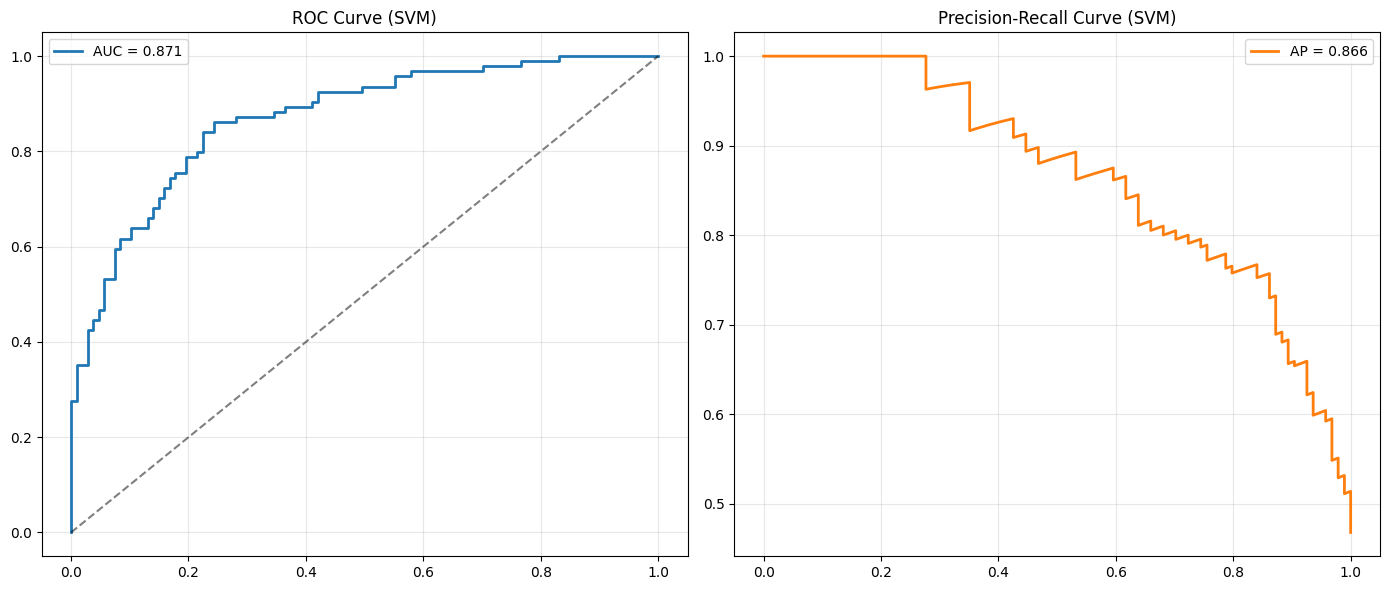

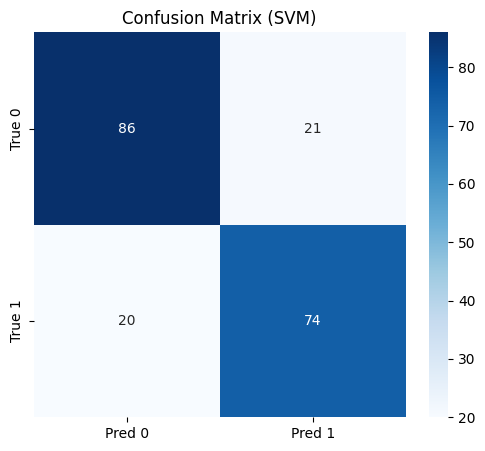

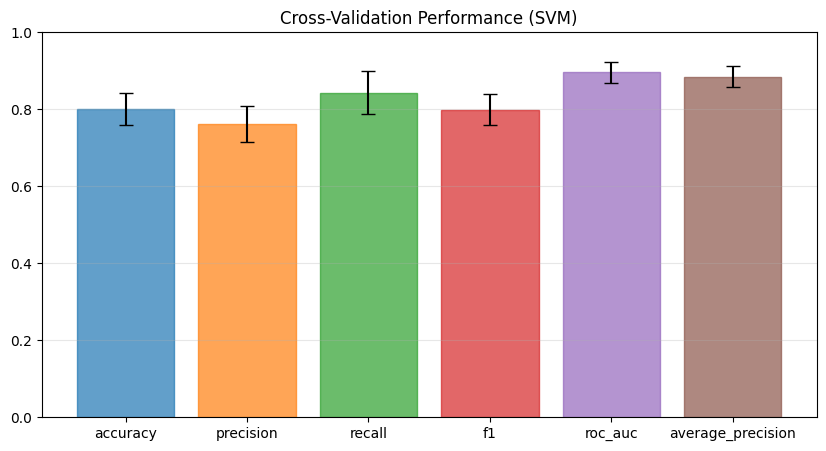


💾 SAVING OUTPUTS to BF6_svm_outputs/ ...
✅ All files saved successfully.

✅ DONE.


In [ ]:
"""
Reusable KNN & SVM Pipeline for Microfinance Impact Analysis
------------------------------------------------------------
Matches the output style of the Random Forest script (Graphs, Validations, Excel).

Usage:
    run_comprehensive_model_analysis(target_bf="BF1", model_type="svm")
    run_comprehensive_model_analysis(target_bf="BF3", model_type="knn")
"""

# ===========
# 0) IMPORTS
# ===========
import os, io, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42

# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e

def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df

# =========================================================
# 2) TARGET SELECTION
# =========================================================
def detect_bf_target(df: pd.DataFrame, target_bf: str = "BF1") -> str:
    m = re.match(r"^\s*BF\s*(\d+)\s*$", str(target_bf), flags=re.I)
    if not m:
        raise ValueError(f"target_bf must look like 'BF1', 'BF3', etc. Got: {target_bf}")

    k = m.group(1)
    aliases = [f"BF{k}", f"bf{k}", f"BF_{k}", f"bf_{k}"]

    for a in aliases:
        if a in df.columns:
            print(f"🎯 Found target column: {a}")
            return a

    pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
    for col in df.columns:
        if pat.search(str(col)):
            print(f"🎯 Found target column (regex match): {col}")
            return col

    print(f"❌ {target_bf} column not found automatically.")
    print("📊 Available columns:", df.columns.tolist())
    user_col = input(f"🔍 Enter exact column name for {target_bf}: ").strip()
    return user_col

def preprocess_bf_target(y_series: pd.Series, target_label: str):
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label}")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:\n", y_clean.value_counts().sort_index())

    y_binary = y_clean.astype(int)
    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask

# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    X_final = X_imputed[non_constant_cols]

    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols

# =========================================================
# 4) MODEL DEFINITIONS
# =========================================================
def get_model_pipeline(model_type, n_samples=None):
    """Returns a pipeline with Scaler + Classifier based on model_type."""

    # Preprocessing (Scaling is MANDATORY for SVM/KNN)
    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    if model_type == "knn":
        # Dynamic K: Sqrt(N) is a good rule of thumb, but keep it odd
        k = int(np.sqrt(n_samples)) if n_samples else 5
        if k % 2 == 0: k += 1
        print(f"⚙️ Configured KNN with n_neighbors={k}")

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    elif model_type == "svm":
        print("⚙️ Configured SVM (RBF Kernel, C=1.0, Probability=True)")
        clf = SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,  # Needed for ROC Curves
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError("model_type must be 'knn' or 'svm'")

    return Pipeline([("pre", preprocessor), ("clf", clf)])

# =========================================================
# 5) CROSS-VALIDATION
# =========================================================
def perform_cross_validation(X, y, model_type, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION ({model_type.upper()})")
    print("=" * 50)

    pipe = get_model_pipeline(model_type, n_samples=len(X))

    scoring = {
        "accuracy": "accuracy", "precision": "precision", "recall": "recall",
        "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        metrics_summary[metric] = {
            "test_mean": float(np.mean(test_scores)),
            "test_std": float(np.std(test_scores)),
            "train_mean": float(np.mean(train_scores))
        }
        print(f"{metric.upper():<15}: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    return metrics_summary, cv_results

# =========================================================
# 6) TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING SPLITS (Val={validation_size})")
    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

def train_model_comprehensive(X, y, model_type, use_validation_set=True):
    print(f"\n🎯 MODEL TRAINING: {model_type.upper()}")
    print("-" * 40)

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
        X_val, y_val = None, None

    # Get pipeline with correct scaling + classifier
    pipe = get_model_pipeline(model_type, n_samples=len(X_train))

    print("🔧 Fitting model...")
    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, X_val, y_train, y_test, y_val

# =========================================================
# 7) EVALUATION & VISUALIZATION
# =========================================================
def evaluate_model_metrics(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET EVALUATION")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"🎯 {k.capitalize():<10}: {v:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"📊 {dataset_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_proba, metrics

def create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    # 1. ROC & PR Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_title(f"ROC Curve ({model_type.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_title(f"Precision-Recall Curve ({model_type.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200)
    plt.show()

    # 2. Confusion Matrix
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200)
    plt.show()

    # 3. CV Comparison
    if cv_metrics:
        names = list(cv_metrics.keys())
        means = [cv_metrics[m]["test_mean"] for m in names]
        stds = [cv_metrics[m]["test_std"] for m in names]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        for i, b in enumerate(bars): b.set_color(f"C{i}")
        plt.title(f"Cross-Validation Performance ({model_type.upper()})")
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/{prefix}_cv_results.png", dpi=200)
        plt.show()

# =========================================================
# 8) SAVING RESULTS
# =========================================================
def save_results(model, metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")

    # 1. Metrics Text File
    with open(f"{output_dir}/{prefix}_metrics.txt", "w") as f:
        f.write(f"MODEL RESULTS: {prefix.upper()}\n{'='*40}\n")
        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")

        if cv_metrics:
            f.write("\nCROSS-VALIDATION:\n")
            for k, v in cv_metrics.items():
                f.write(f"{k}: {v['test_mean']:.4f} ± {v['test_std']:.4f}\n")

    # 2. Excel Predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore").reindex(columns=feature_names)
    preds = model.predict_proba(X_full)[:, 1]

    out_df = df_clean.copy()
    out_df[f"{prefix}_Prob"] = preds
    out_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    out_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)

    # 3. Model
    joblib.dump(model, f"{output_dir}/{prefix}_model.joblib")
    print("✅ All files saved successfully.")

# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run_comprehensive_model_analysis(target_bf="BF1", model_type="svm", df=None):
    """
    Run pipeline for SVM or KNN.
    model_type: 'svm' or 'knn'
    """
    try:
        model_type = model_type.lower()
        prefix = f"{target_bf}_{model_type}"
        output_dir = f"{prefix}_outputs"

        print(f"🚀 STARTING ANALYSIS: {model_type.upper()} on {target_bf}")

        if df is None:
            try: df = load_excel_from_colab()
            except: df = load_excel_locally()

        # Target Setup
        target_col = detect_bf_target(df, target_bf)
        y, valid_mask = preprocess_bf_target(df[target_col], target_col)
        df_clean = df.loc[valid_mask].copy()

        # Features
        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        # 1. CV
        cv_metrics, _ = perform_cross_validation(X_final, y, model_type, cv_folds=10)

        # 2. Train
        model, X_train, X_test, X_val, y_train, y_test, y_val = train_model_comprehensive(
            X_final, y, model_type, use_validation_set=True
        )

        # 3. Eval
        _, y_proba, test_metrics = evaluate_model_metrics(model, X_test, y_test, "Test")

        # 4. Viz
        create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics)

        # 5. Save
        save_results(model, test_metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics)

        print("\n✅ DONE.")
        return model

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None

# ========= USAGE =========
if __name__ == "__main__":
    # Example 1: Run SVM on BF6 (Default)
    run_comprehensive_model_analysis(target_bf="BF6", model_type="svm")

    # Example 2: Run KNN (Uncomment to use)
    # run_comprehensive_model_analysis(target_bf="BF6", model_type="knn")

🚀 STARTING ANALYSIS: SVM on BF6
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (2).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
❌ BF6 column not found automatically.
📊 Available columns: ['D', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE_01', 'BE_02', 'BE_03', 'BE_04', 'BE_05', 'BE_06', 'BE_07', 'BE_08', 'BE_09', 'BE_10', 'BF', 'BG_01', 'BG_02', 'BG_03', 'BG_04', 'BG_05', 'BG_06', 'BH', 'BI', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW_01', 'BW_02', 'BW_03', 'BW_04', 'BW_05', 'BX', 'BY', 'CB', 'CD', 'CE', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL', 'CM_01', 'CM_02', 'CM_03', 'CM_04', 'CM_05', 'CM_06', 'CN', 'CO_01', 'CO_02', 'CO_03', 'CO_04', 'CO_05', 'CO_06', 'CO_07', 'CO_08', 'CO_09', 'CP', 'CR_01', 'CR_02', 'CR_03', 'CR_04', 'CS', 'CT_01', 'CT_02', 'CT_03', 'CT_04', 'CT_05', 'CT_06', 'CU', 'Occupation', 'Financial Behavior', 'Family', 'Lifestyle', 'Digital Literacy']
🔍 Enter exact column name for BF6: BG_03

📈 TARGET ANALYSIS: BG_03
----------------------------------------
Value distributi

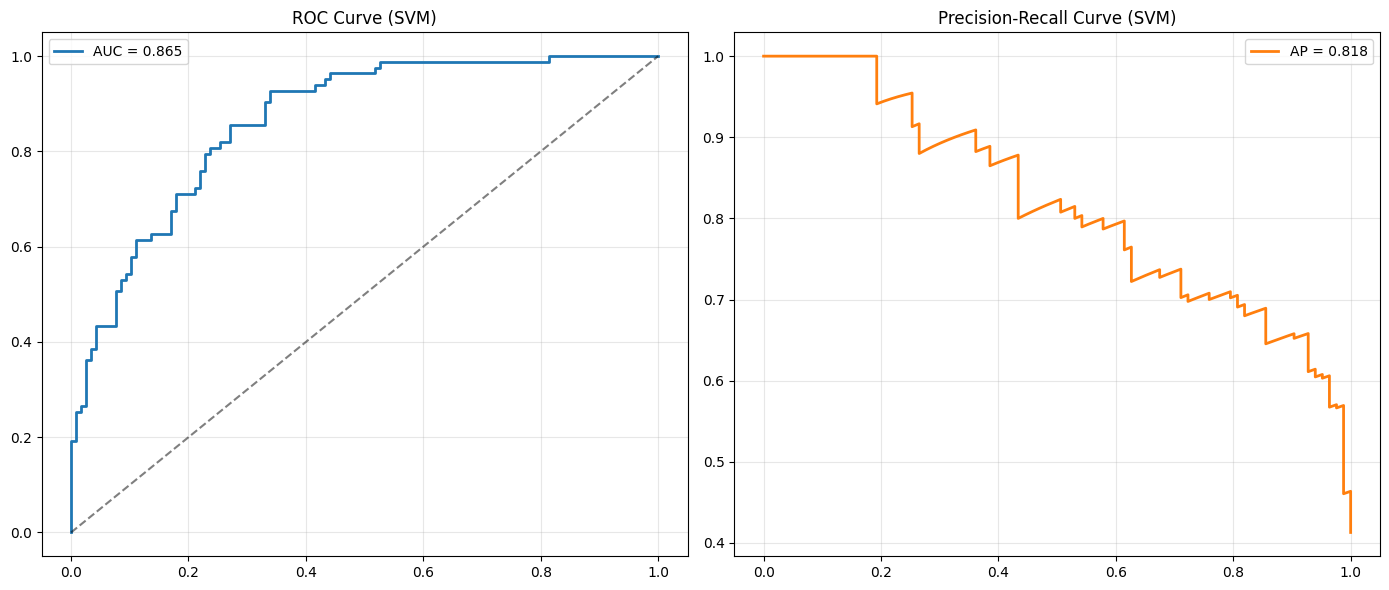

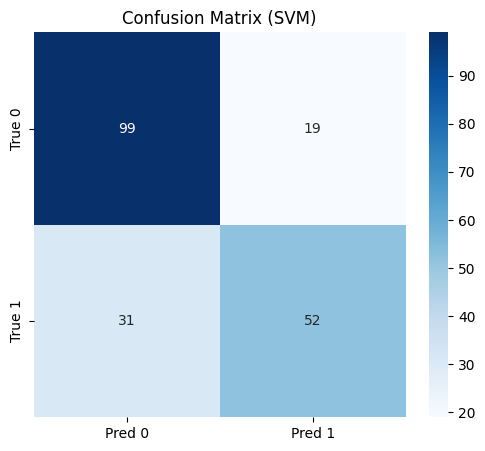

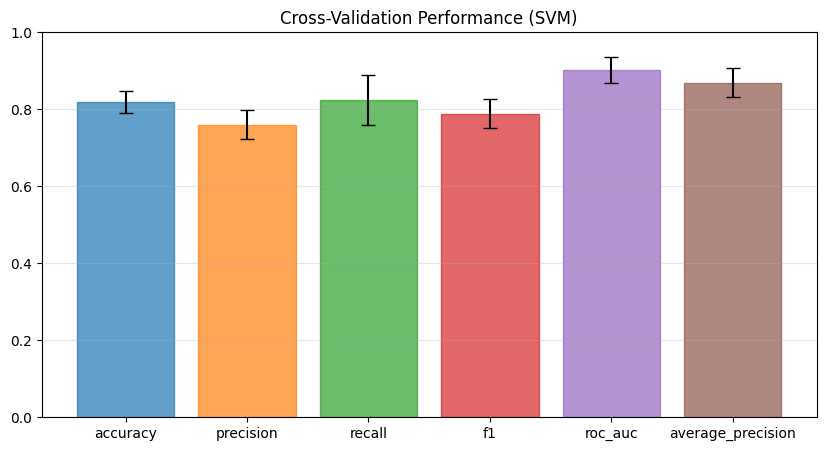


💾 SAVING OUTPUTS to BF6_svm_outputs/ ...
✅ All files saved successfully.

✅ DONE.


In [ ]:
"""
Reusable KNN & SVM Pipeline for Microfinance Impact Analysis
------------------------------------------------------------
Matches the output style of the Random Forest script (Graphs, Validations, Excel).

Usage:
    run_comprehensive_model_analysis(target_bf="BF1", model_type="svm")
    run_comprehensive_model_analysis(target_bf="BF3", model_type="knn")
"""

# ===========
# 0) IMPORTS
# ===========
import os, io, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42

# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e

def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df

# =========================================================
# 2) TARGET SELECTION
# =========================================================
def detect_bf_target(df: pd.DataFrame, target_bf: str = "BF1") -> str:
    m = re.match(r"^\s*BF\s*(\d+)\s*$", str(target_bf), flags=re.I)
    if not m:
        raise ValueError(f"target_bf must look like 'BF1', 'BF3', etc. Got: {target_bf}")

    k = m.group(1)
    aliases = [f"BF{k}", f"bf{k}", f"BF_{k}", f"bf_{k}"]

    for a in aliases:
        if a in df.columns:
            print(f"🎯 Found target column: {a}")
            return a

    pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
    for col in df.columns:
        if pat.search(str(col)):
            print(f"🎯 Found target column (regex match): {col}")
            return col

    print(f"❌ {target_bf} column not found automatically.")
    print("📊 Available columns:", df.columns.tolist())
    user_col = input(f"🔍 Enter exact column name for {target_bf}: ").strip()
    return user_col

def preprocess_bf_target(y_series: pd.Series, target_label: str):
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label}")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:\n", y_clean.value_counts().sort_index())

    y_binary = y_clean.astype(int)
    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask

# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    X_final = X_imputed[non_constant_cols]

    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols

# =========================================================
# 4) MODEL DEFINITIONS
# =========================================================
def get_model_pipeline(model_type, n_samples=None):
    """Returns a pipeline with Scaler + Classifier based on model_type."""

    # Preprocessing (Scaling is MANDATORY for SVM/KNN)
    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    if model_type == "knn":
        # Dynamic K: Sqrt(N) is a good rule of thumb, but keep it odd
        k = int(np.sqrt(n_samples)) if n_samples else 5
        if k % 2 == 0: k += 1
        print(f"⚙️ Configured KNN with n_neighbors={k}")

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    elif model_type == "svm":
        print("⚙️ Configured SVM (RBF Kernel, C=1.0, Probability=True)")
        clf = SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,  # Needed for ROC Curves
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError("model_type must be 'knn' or 'svm'")

    return Pipeline([("pre", preprocessor), ("clf", clf)])

# =========================================================
# 5) CROSS-VALIDATION
# =========================================================
def perform_cross_validation(X, y, model_type, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION ({model_type.upper()})")
    print("=" * 50)

    pipe = get_model_pipeline(model_type, n_samples=len(X))

    scoring = {
        "accuracy": "accuracy", "precision": "precision", "recall": "recall",
        "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        metrics_summary[metric] = {
            "test_mean": float(np.mean(test_scores)),
            "test_std": float(np.std(test_scores)),
            "train_mean": float(np.mean(train_scores))
        }
        print(f"{metric.upper():<15}: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    return metrics_summary, cv_results

# =========================================================
# 6) TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING SPLITS (Val={validation_size})")
    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

def train_model_comprehensive(X, y, model_type, use_validation_set=True):
    print(f"\n🎯 MODEL TRAINING: {model_type.upper()}")
    print("-" * 40)

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
        X_val, y_val = None, None

    # Get pipeline with correct scaling + classifier
    pipe = get_model_pipeline(model_type, n_samples=len(X_train))

    print("🔧 Fitting model...")
    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, X_val, y_train, y_test, y_val

# =========================================================
# 7) EVALUATION & VISUALIZATION
# =========================================================
def evaluate_model_metrics(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET EVALUATION")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"🎯 {k.capitalize():<10}: {v:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"📊 {dataset_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_proba, metrics

def create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    # 1. ROC & PR Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_title(f"ROC Curve ({model_type.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_title(f"Precision-Recall Curve ({model_type.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200)
    plt.show()

    # 2. Confusion Matrix
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200)
    plt.show()

    # 3. CV Comparison
    if cv_metrics:
        names = list(cv_metrics.keys())
        means = [cv_metrics[m]["test_mean"] for m in names]
        stds = [cv_metrics[m]["test_std"] for m in names]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        for i, b in enumerate(bars): b.set_color(f"C{i}")
        plt.title(f"Cross-Validation Performance ({model_type.upper()})")
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/{prefix}_cv_results.png", dpi=200)
        plt.show()

# =========================================================
# 8) SAVING RESULTS
# =========================================================
def save_results(model, metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")

    # 1. Metrics Text File
    with open(f"{output_dir}/{prefix}_metrics.txt", "w") as f:
        f.write(f"MODEL RESULTS: {prefix.upper()}\n{'='*40}\n")
        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")

        if cv_metrics:
            f.write("\nCROSS-VALIDATION:\n")
            for k, v in cv_metrics.items():
                f.write(f"{k}: {v['test_mean']:.4f} ± {v['test_std']:.4f}\n")

    # 2. Excel Predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore").reindex(columns=feature_names)
    preds = model.predict_proba(X_full)[:, 1]

    out_df = df_clean.copy()
    out_df[f"{prefix}_Prob"] = preds
    out_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    out_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)

    # 3. Model
    joblib.dump(model, f"{output_dir}/{prefix}_model.joblib")
    print("✅ All files saved successfully.")

# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run_comprehensive_model_analysis(target_bf="BF1", model_type="svm", df=None):
    """
    Run pipeline for SVM or KNN.
    model_type: 'svm' or 'knn'
    """
    try:
        model_type = model_type.lower()
        prefix = f"{target_bf}_{model_type}"
        output_dir = f"{prefix}_outputs"

        print(f"🚀 STARTING ANALYSIS: {model_type.upper()} on {target_bf}")

        if df is None:
            try: df = load_excel_from_colab()
            except: df = load_excel_locally()

        # Target Setup
        target_col = detect_bf_target(df, target_bf)
        y, valid_mask = preprocess_bf_target(df[target_col], target_col)
        df_clean = df.loc[valid_mask].copy()

        # Features
        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        # 1. CV
        cv_metrics, _ = perform_cross_validation(X_final, y, model_type, cv_folds=10)

        # 2. Train
        model, X_train, X_test, X_val, y_train, y_test, y_val = train_model_comprehensive(
            X_final, y, model_type, use_validation_set=True
        )

        # 3. Eval
        _, y_proba, test_metrics = evaluate_model_metrics(model, X_test, y_test, "Test")

        # 4. Viz
        create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics)

        # 5. Save
        save_results(model, test_metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics)

        print("\n✅ DONE.")
        return model

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None

# ========= USAGE =========
if __name__ == "__main__":
    # Example 1: Run SVM on BF6 (Default)
    run_comprehensive_model_analysis(target_bf="BF6", model_type="svm")

    # Example 2: Run KNN (Uncomment to use)
    # run_comprehensive_model_analysis(target_bf="BF6", model_type="knn")

🚀 STARTING ANALYSIS: SVM on BF6
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (3).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
❌ BF6 column not found automatically.
📊 Available columns: ['D', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE_01', 'BE_02', 'BE_03', 'BE_04', 'BE_05', 'BE_06', 'BE_07', 'BE_08', 'BE_09', 'BE_10', 'BF', 'BG_01', 'BG_02', 'BG_03', 'BG_04', 'BG_05', 'BG_06', 'BH', 'BI', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW_01', 'BW_02', 'BW_03', 'BW_04', 'BW_05', 'BX', 'BY', 'CB', 'CD', 'CE', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL', 'CM_01', 'CM_02', 'CM_03', 'CM_04', 'CM_05', 'CM_06', 'CN', 'CO_01', 'CO_02', 'CO_03', 'CO_04', 'CO_05', 'CO_06', 'CO_07', 'CO_08', 'CO_09', 'CP', 'CR_01', 'CR_02', 'CR_03', 'CR_04', 'CS', 'CT_01', 'CT_02', 'CT_03', 'CT_04', 'CT_05', 'CT_06', 'CU', 'Occupation', 'Financial Behavior', 'Family', 'Lifestyle', 'Digital Literacy']
🔍 Enter exact column name for BF6: BG_04

📈 TARGET ANALYSIS: BG_04
----------------------------------------
Value distributi

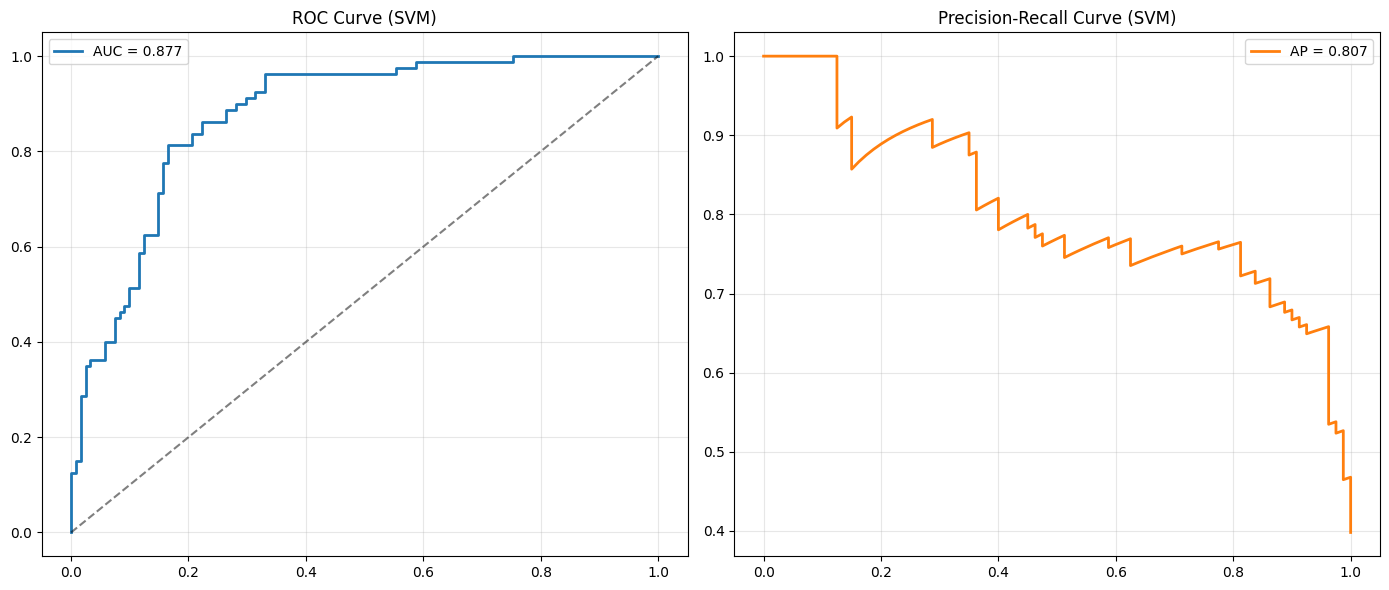

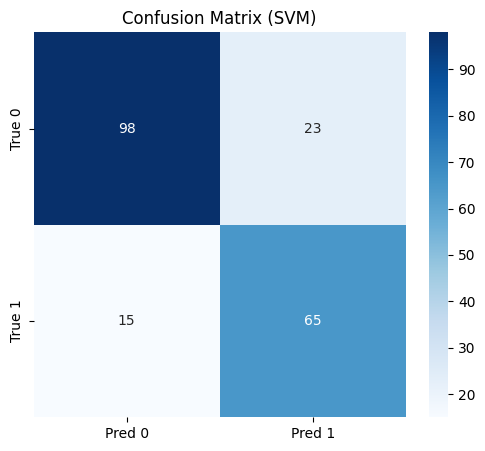

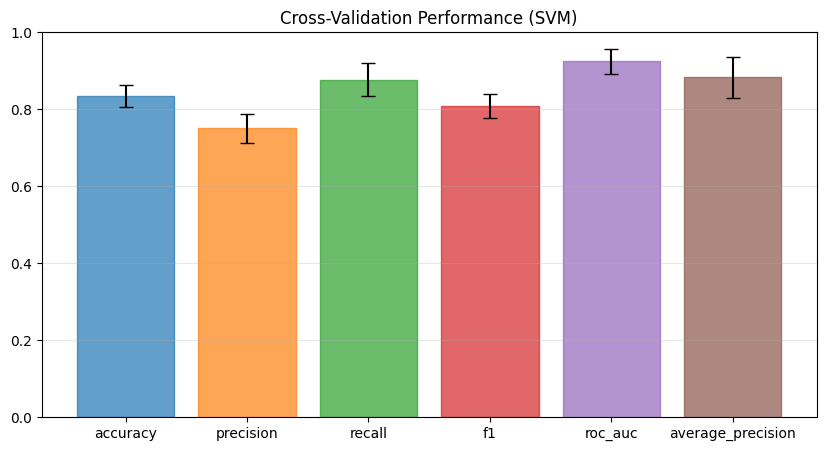


💾 SAVING OUTPUTS to BF6_svm_outputs/ ...
✅ All files saved successfully.

✅ DONE.


In [ ]:
"""
Reusable KNN & SVM Pipeline for Microfinance Impact Analysis
------------------------------------------------------------
Matches the output style of the Random Forest script (Graphs, Validations, Excel).

Usage:
    run_comprehensive_model_analysis(target_bf="BF1", model_type="svm")
    run_comprehensive_model_analysis(target_bf="BF3", model_type="knn")
"""

# ===========
# 0) IMPORTS
# ===========
import os, io, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42

# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e

def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df

# =========================================================
# 2) TARGET SELECTION
# =========================================================
def detect_bf_target(df: pd.DataFrame, target_bf: str = "BF1") -> str:
    m = re.match(r"^\s*BF\s*(\d+)\s*$", str(target_bf), flags=re.I)
    if not m:
        raise ValueError(f"target_bf must look like 'BF1', 'BF3', etc. Got: {target_bf}")

    k = m.group(1)
    aliases = [f"BF{k}", f"bf{k}", f"BF_{k}", f"bf_{k}"]

    for a in aliases:
        if a in df.columns:
            print(f"🎯 Found target column: {a}")
            return a

    pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
    for col in df.columns:
        if pat.search(str(col)):
            print(f"🎯 Found target column (regex match): {col}")
            return col

    print(f"❌ {target_bf} column not found automatically.")
    print("📊 Available columns:", df.columns.tolist())
    user_col = input(f"🔍 Enter exact column name for {target_bf}: ").strip()
    return user_col

def preprocess_bf_target(y_series: pd.Series, target_label: str):
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label}")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:\n", y_clean.value_counts().sort_index())

    y_binary = y_clean.astype(int)
    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask

# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    X_final = X_imputed[non_constant_cols]

    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols

# =========================================================
# 4) MODEL DEFINITIONS
# =========================================================
def get_model_pipeline(model_type, n_samples=None):
    """Returns a pipeline with Scaler + Classifier based on model_type."""

    # Preprocessing (Scaling is MANDATORY for SVM/KNN)
    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    if model_type == "knn":
        # Dynamic K: Sqrt(N) is a good rule of thumb, but keep it odd
        k = int(np.sqrt(n_samples)) if n_samples else 5
        if k % 2 == 0: k += 1
        print(f"⚙️ Configured KNN with n_neighbors={k}")

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    elif model_type == "svm":
        print("⚙️ Configured SVM (RBF Kernel, C=1.0, Probability=True)")
        clf = SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,  # Needed for ROC Curves
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError("model_type must be 'knn' or 'svm'")

    return Pipeline([("pre", preprocessor), ("clf", clf)])

# =========================================================
# 5) CROSS-VALIDATION
# =========================================================
def perform_cross_validation(X, y, model_type, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION ({model_type.upper()})")
    print("=" * 50)

    pipe = get_model_pipeline(model_type, n_samples=len(X))

    scoring = {
        "accuracy": "accuracy", "precision": "precision", "recall": "recall",
        "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        metrics_summary[metric] = {
            "test_mean": float(np.mean(test_scores)),
            "test_std": float(np.std(test_scores)),
            "train_mean": float(np.mean(train_scores))
        }
        print(f"{metric.upper():<15}: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    return metrics_summary, cv_results

# =========================================================
# 6) TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING SPLITS (Val={validation_size})")
    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

def train_model_comprehensive(X, y, model_type, use_validation_set=True):
    print(f"\n🎯 MODEL TRAINING: {model_type.upper()}")
    print("-" * 40)

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
        X_val, y_val = None, None

    # Get pipeline with correct scaling + classifier
    pipe = get_model_pipeline(model_type, n_samples=len(X_train))

    print("🔧 Fitting model...")
    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, X_val, y_train, y_test, y_val

# =========================================================
# 7) EVALUATION & VISUALIZATION
# =========================================================
def evaluate_model_metrics(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET EVALUATION")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"🎯 {k.capitalize():<10}: {v:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"📊 {dataset_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_proba, metrics

def create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    # 1. ROC & PR Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_title(f"ROC Curve ({model_type.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_title(f"Precision-Recall Curve ({model_type.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200)
    plt.show()

    # 2. Confusion Matrix
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200)
    plt.show()

    # 3. CV Comparison
    if cv_metrics:
        names = list(cv_metrics.keys())
        means = [cv_metrics[m]["test_mean"] for m in names]
        stds = [cv_metrics[m]["test_std"] for m in names]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        for i, b in enumerate(bars): b.set_color(f"C{i}")
        plt.title(f"Cross-Validation Performance ({model_type.upper()})")
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/{prefix}_cv_results.png", dpi=200)
        plt.show()

# =========================================================
# 8) SAVING RESULTS
# =========================================================
def save_results(model, metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")

    # 1. Metrics Text File
    with open(f"{output_dir}/{prefix}_metrics.txt", "w") as f:
        f.write(f"MODEL RESULTS: {prefix.upper()}\n{'='*40}\n")
        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")

        if cv_metrics:
            f.write("\nCROSS-VALIDATION:\n")
            for k, v in cv_metrics.items():
                f.write(f"{k}: {v['test_mean']:.4f} ± {v['test_std']:.4f}\n")

    # 2. Excel Predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore").reindex(columns=feature_names)
    preds = model.predict_proba(X_full)[:, 1]

    out_df = df_clean.copy()
    out_df[f"{prefix}_Prob"] = preds
    out_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    out_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)

    # 3. Model
    joblib.dump(model, f"{output_dir}/{prefix}_model.joblib")
    print("✅ All files saved successfully.")

# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run_comprehensive_model_analysis(target_bf="BF1", model_type="svm", df=None):
    """
    Run pipeline for SVM or KNN.
    model_type: 'svm' or 'knn'
    """
    try:
        model_type = model_type.lower()
        prefix = f"{target_bf}_{model_type}"
        output_dir = f"{prefix}_outputs"

        print(f"🚀 STARTING ANALYSIS: {model_type.upper()} on {target_bf}")

        if df is None:
            try: df = load_excel_from_colab()
            except: df = load_excel_locally()

        # Target Setup
        target_col = detect_bf_target(df, target_bf)
        y, valid_mask = preprocess_bf_target(df[target_col], target_col)
        df_clean = df.loc[valid_mask].copy()

        # Features
        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        # 1. CV
        cv_metrics, _ = perform_cross_validation(X_final, y, model_type, cv_folds=10)

        # 2. Train
        model, X_train, X_test, X_val, y_train, y_test, y_val = train_model_comprehensive(
            X_final, y, model_type, use_validation_set=True
        )

        # 3. Eval
        _, y_proba, test_metrics = evaluate_model_metrics(model, X_test, y_test, "Test")

        # 4. Viz
        create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics)

        # 5. Save
        save_results(model, test_metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics)

        print("\n✅ DONE.")
        return model

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None

# ========= USAGE =========
if __name__ == "__main__":
    # Example 1: Run SVM on BF6 (Default)
    run_comprehensive_model_analysis(target_bf="BF6", model_type="svm")

    # Example 2: Run KNN (Uncomment to use)
    # run_comprehensive_model_analysis(target_bf="BF6", model_type="knn")

🚀 STARTING ANALYSIS: SVM on BF6
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (4).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
❌ BF6 column not found automatically.
📊 Available columns: ['D', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE_01', 'BE_02', 'BE_03', 'BE_04', 'BE_05', 'BE_06', 'BE_07', 'BE_08', 'BE_09', 'BE_10', 'BF', 'BG_01', 'BG_02', 'BG_03', 'BG_04', 'BG_05', 'BG_06', 'BH', 'BI', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW_01', 'BW_02', 'BW_03', 'BW_04', 'BW_05', 'BX', 'BY', 'CB', 'CD', 'CE', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL', 'CM_01', 'CM_02', 'CM_03', 'CM_04', 'CM_05', 'CM_06', 'CN', 'CO_01', 'CO_02', 'CO_03', 'CO_04', 'CO_05', 'CO_06', 'CO_07', 'CO_08', 'CO_09', 'CP', 'CR_01', 'CR_02', 'CR_03', 'CR_04', 'CS', 'CT_01', 'CT_02', 'CT_03', 'CT_04', 'CT_05', 'CT_06', 'CU', 'Occupation', 'Financial Behavior', 'Family', 'Lifestyle', 'Digital Literacy']
🔍 Enter exact column name for BF6: BG_05

📈 TARGET ANALYSIS: BG_05
----------------------------------------
Value distributi

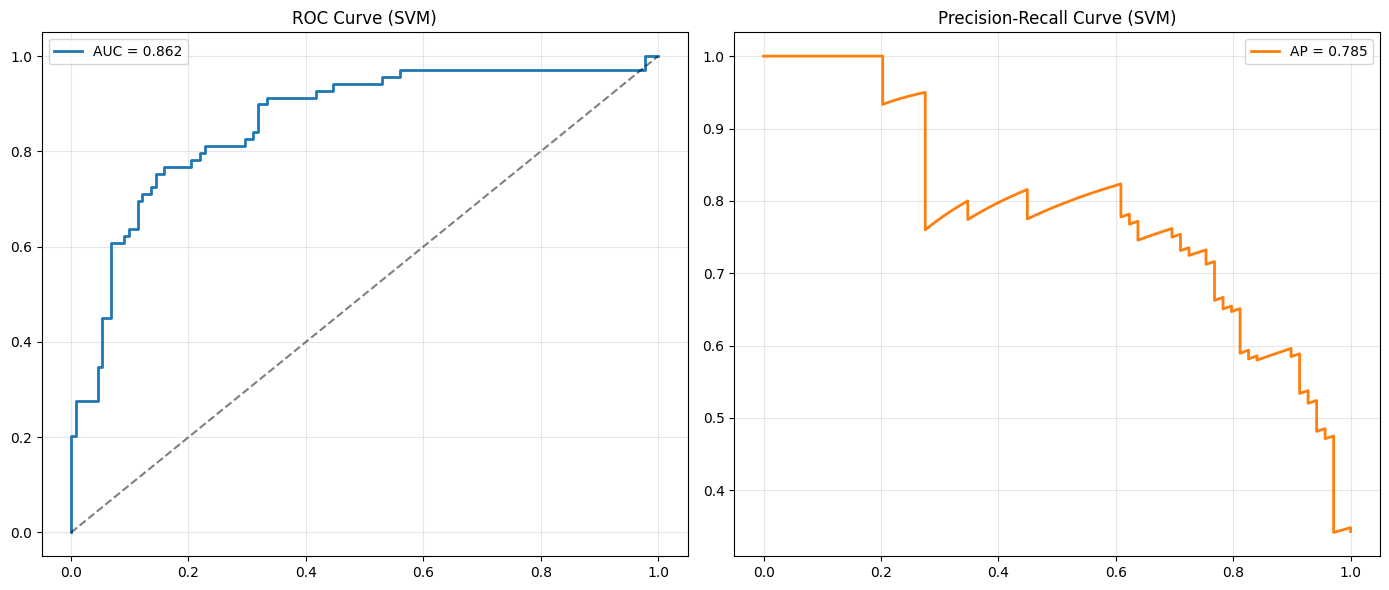

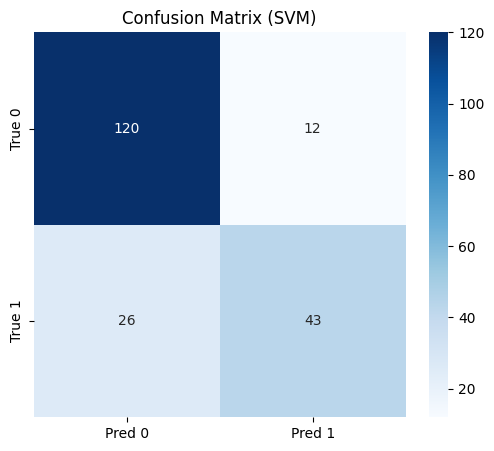

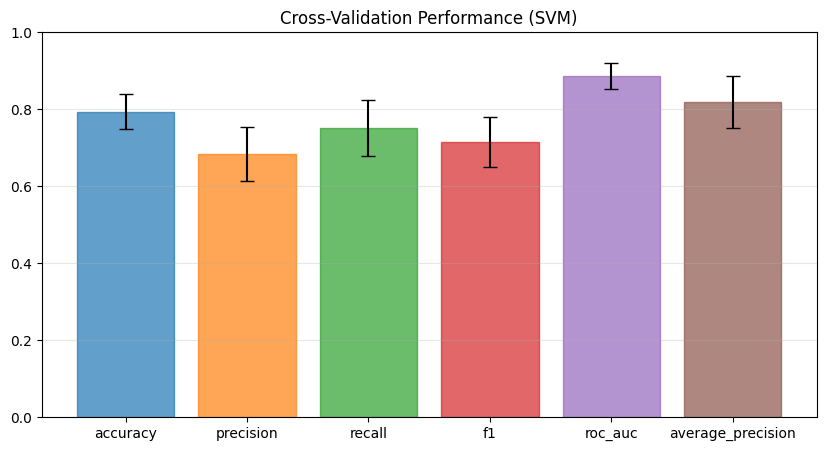


💾 SAVING OUTPUTS to BF6_svm_outputs/ ...
✅ All files saved successfully.

✅ DONE.


In [ ]:
"""
Reusable KNN & SVM Pipeline for Microfinance Impact Analysis
------------------------------------------------------------
Matches the output style of the Random Forest script (Graphs, Validations, Excel).

Usage:
    run_comprehensive_model_analysis(target_bf="BF1", model_type="svm")
    run_comprehensive_model_analysis(target_bf="BF3", model_type="knn")
"""

# ===========
# 0) IMPORTS
# ===========
import os, io, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42

# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e

def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df

# =========================================================
# 2) TARGET SELECTION
# =========================================================
def detect_bf_target(df: pd.DataFrame, target_bf: str = "BF1") -> str:
    m = re.match(r"^\s*BF\s*(\d+)\s*$", str(target_bf), flags=re.I)
    if not m:
        raise ValueError(f"target_bf must look like 'BF1', 'BF3', etc. Got: {target_bf}")

    k = m.group(1)
    aliases = [f"BF{k}", f"bf{k}", f"BF_{k}", f"bf_{k}"]

    for a in aliases:
        if a in df.columns:
            print(f"🎯 Found target column: {a}")
            return a

    pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
    for col in df.columns:
        if pat.search(str(col)):
            print(f"🎯 Found target column (regex match): {col}")
            return col

    print(f"❌ {target_bf} column not found automatically.")
    print("📊 Available columns:", df.columns.tolist())
    user_col = input(f"🔍 Enter exact column name for {target_bf}: ").strip()
    return user_col

def preprocess_bf_target(y_series: pd.Series, target_label: str):
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label}")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:\n", y_clean.value_counts().sort_index())

    y_binary = y_clean.astype(int)
    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask

# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    X_final = X_imputed[non_constant_cols]

    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols

# =========================================================
# 4) MODEL DEFINITIONS
# =========================================================
def get_model_pipeline(model_type, n_samples=None):
    """Returns a pipeline with Scaler + Classifier based on model_type."""

    # Preprocessing (Scaling is MANDATORY for SVM/KNN)
    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    if model_type == "knn":
        # Dynamic K: Sqrt(N) is a good rule of thumb, but keep it odd
        k = int(np.sqrt(n_samples)) if n_samples else 5
        if k % 2 == 0: k += 1
        print(f"⚙️ Configured KNN with n_neighbors={k}")

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    elif model_type == "svm":
        print("⚙️ Configured SVM (RBF Kernel, C=1.0, Probability=True)")
        clf = SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,  # Needed for ROC Curves
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError("model_type must be 'knn' or 'svm'")

    return Pipeline([("pre", preprocessor), ("clf", clf)])

# =========================================================
# 5) CROSS-VALIDATION
# =========================================================
def perform_cross_validation(X, y, model_type, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION ({model_type.upper()})")
    print("=" * 50)

    pipe = get_model_pipeline(model_type, n_samples=len(X))

    scoring = {
        "accuracy": "accuracy", "precision": "precision", "recall": "recall",
        "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        metrics_summary[metric] = {
            "test_mean": float(np.mean(test_scores)),
            "test_std": float(np.std(test_scores)),
            "train_mean": float(np.mean(train_scores))
        }
        print(f"{metric.upper():<15}: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    return metrics_summary, cv_results

# =========================================================
# 6) TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING SPLITS (Val={validation_size})")
    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

def train_model_comprehensive(X, y, model_type, use_validation_set=True):
    print(f"\n🎯 MODEL TRAINING: {model_type.upper()}")
    print("-" * 40)

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
        X_val, y_val = None, None

    # Get pipeline with correct scaling + classifier
    pipe = get_model_pipeline(model_type, n_samples=len(X_train))

    print("🔧 Fitting model...")
    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, X_val, y_train, y_test, y_val

# =========================================================
# 7) EVALUATION & VISUALIZATION
# =========================================================
def evaluate_model_metrics(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET EVALUATION")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"🎯 {k.capitalize():<10}: {v:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"📊 {dataset_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_proba, metrics

def create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    # 1. ROC & PR Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_title(f"ROC Curve ({model_type.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_title(f"Precision-Recall Curve ({model_type.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200)
    plt.show()

    # 2. Confusion Matrix
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200)
    plt.show()

    # 3. CV Comparison
    if cv_metrics:
        names = list(cv_metrics.keys())
        means = [cv_metrics[m]["test_mean"] for m in names]
        stds = [cv_metrics[m]["test_std"] for m in names]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        for i, b in enumerate(bars): b.set_color(f"C{i}")
        plt.title(f"Cross-Validation Performance ({model_type.upper()})")
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/{prefix}_cv_results.png", dpi=200)
        plt.show()

# =========================================================
# 8) SAVING RESULTS
# =========================================================
def save_results(model, metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")

    # 1. Metrics Text File
    with open(f"{output_dir}/{prefix}_metrics.txt", "w") as f:
        f.write(f"MODEL RESULTS: {prefix.upper()}\n{'='*40}\n")
        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")

        if cv_metrics:
            f.write("\nCROSS-VALIDATION:\n")
            for k, v in cv_metrics.items():
                f.write(f"{k}: {v['test_mean']:.4f} ± {v['test_std']:.4f}\n")

    # 2. Excel Predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore").reindex(columns=feature_names)
    preds = model.predict_proba(X_full)[:, 1]

    out_df = df_clean.copy()
    out_df[f"{prefix}_Prob"] = preds
    out_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    out_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)

    # 3. Model
    joblib.dump(model, f"{output_dir}/{prefix}_model.joblib")
    print("✅ All files saved successfully.")

# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run_comprehensive_model_analysis(target_bf="BF1", model_type="svm", df=None):
    """
    Run pipeline for SVM or KNN.
    model_type: 'svm' or 'knn'
    """
    try:
        model_type = model_type.lower()
        prefix = f"{target_bf}_{model_type}"
        output_dir = f"{prefix}_outputs"

        print(f"🚀 STARTING ANALYSIS: {model_type.upper()} on {target_bf}")

        if df is None:
            try: df = load_excel_from_colab()
            except: df = load_excel_locally()

        # Target Setup
        target_col = detect_bf_target(df, target_bf)
        y, valid_mask = preprocess_bf_target(df[target_col], target_col)
        df_clean = df.loc[valid_mask].copy()

        # Features
        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        # 1. CV
        cv_metrics, _ = perform_cross_validation(X_final, y, model_type, cv_folds=10)

        # 2. Train
        model, X_train, X_test, X_val, y_train, y_test, y_val = train_model_comprehensive(
            X_final, y, model_type, use_validation_set=True
        )

        # 3. Eval
        _, y_proba, test_metrics = evaluate_model_metrics(model, X_test, y_test, "Test")

        # 4. Viz
        create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics)

        # 5. Save
        save_results(model, test_metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics)

        print("\n✅ DONE.")
        return model

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None

# ========= USAGE =========
if __name__ == "__main__":
    # Example 1: Run SVM on BF6 (Default)
    run_comprehensive_model_analysis(target_bf="BF6", model_type="svm")

    # Example 2: Run KNN (Uncomment to use)
    # run_comprehensive_model_analysis(target_bf="BF6", model_type="knn")

🚀 STARTING ANALYSIS: SVM on BF6
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (5).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
❌ BF6 column not found automatically.
📊 Available columns: ['D', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE_01', 'BE_02', 'BE_03', 'BE_04', 'BE_05', 'BE_06', 'BE_07', 'BE_08', 'BE_09', 'BE_10', 'BF', 'BG_01', 'BG_02', 'BG_03', 'BG_04', 'BG_05', 'BG_06', 'BH', 'BI', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW_01', 'BW_02', 'BW_03', 'BW_04', 'BW_05', 'BX', 'BY', 'CB', 'CD', 'CE', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL', 'CM_01', 'CM_02', 'CM_03', 'CM_04', 'CM_05', 'CM_06', 'CN', 'CO_01', 'CO_02', 'CO_03', 'CO_04', 'CO_05', 'CO_06', 'CO_07', 'CO_08', 'CO_09', 'CP', 'CR_01', 'CR_02', 'CR_03', 'CR_04', 'CS', 'CT_01', 'CT_02', 'CT_03', 'CT_04', 'CT_05', 'CT_06', 'CU', 'Occupation', 'Financial Behavior', 'Family', 'Lifestyle', 'Digital Literacy']
🔍 Enter exact column name for BF6: BG_06

📈 TARGET ANALYSIS: BG_06
----------------------------------------
Value distributi

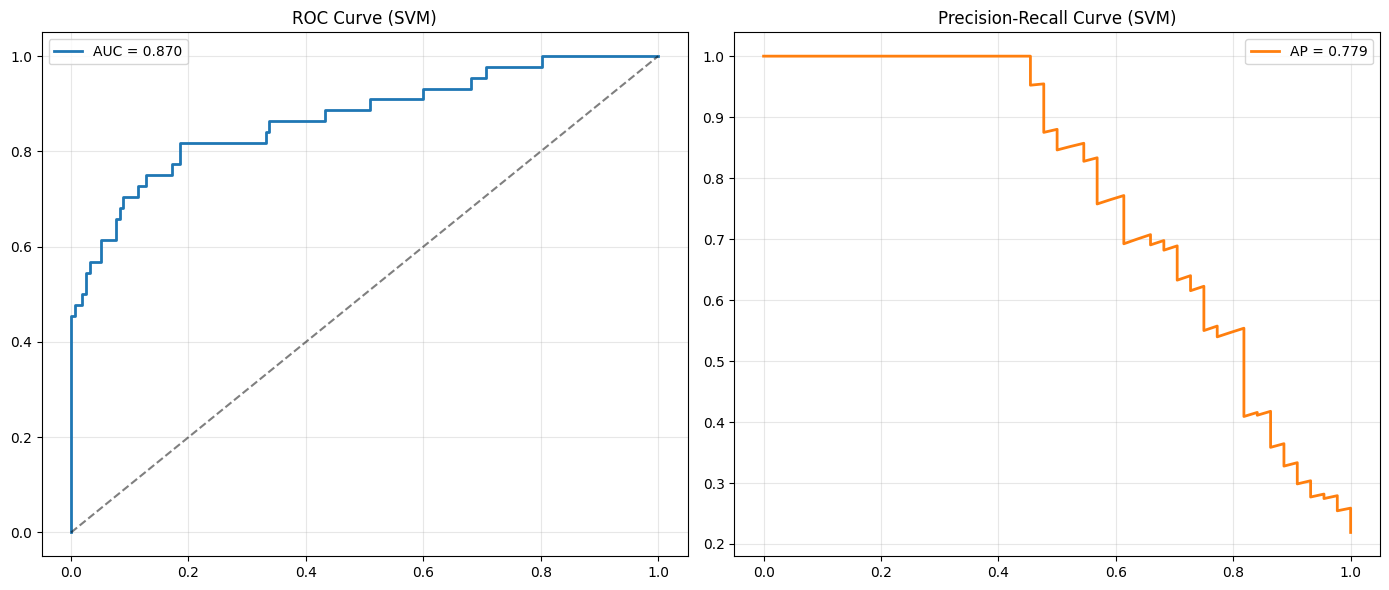

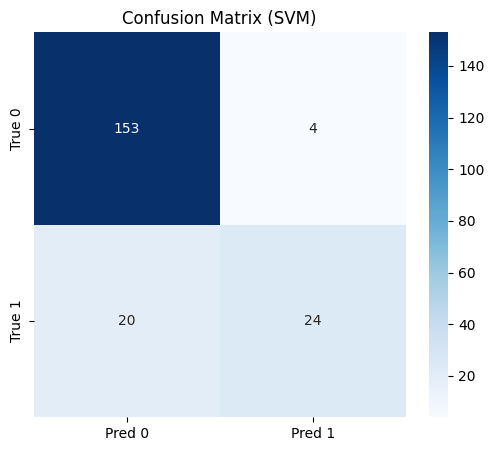

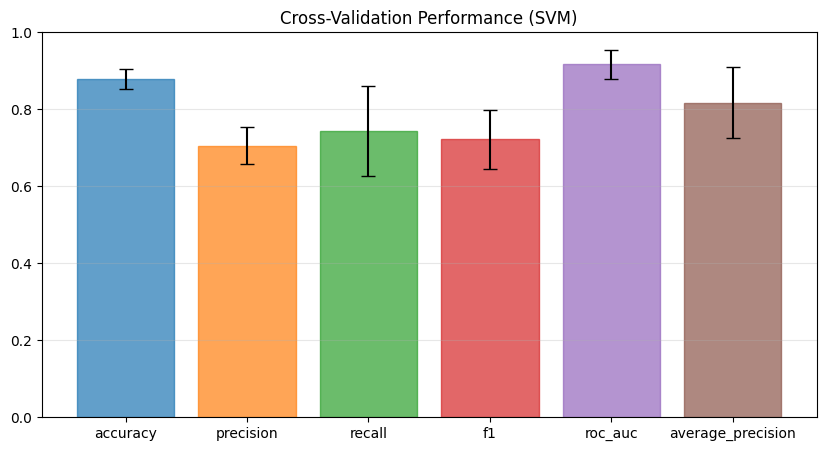


💾 SAVING OUTPUTS to BF6_svm_outputs/ ...
✅ All files saved successfully.

✅ DONE.


In [ ]:
"""
Reusable KNN & SVM Pipeline for Microfinance Impact Analysis
------------------------------------------------------------
Matches the output style of the Random Forest script (Graphs, Validations, Excel).

Usage:
    run_comprehensive_model_analysis(target_bf="BF1", model_type="svm")
    run_comprehensive_model_analysis(target_bf="BF3", model_type="knn")
"""

# ===========
# 0) IMPORTS
# ===========
import os, io, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42

# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e

def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df

# =========================================================
# 2) TARGET SELECTION
# =========================================================
def detect_bf_target(df: pd.DataFrame, target_bf: str = "BF1") -> str:
    m = re.match(r"^\s*BF\s*(\d+)\s*$", str(target_bf), flags=re.I)
    if not m:
        raise ValueError(f"target_bf must look like 'BF1', 'BF3', etc. Got: {target_bf}")

    k = m.group(1)
    aliases = [f"BF{k}", f"bf{k}", f"BF_{k}", f"bf_{k}"]

    for a in aliases:
        if a in df.columns:
            print(f"🎯 Found target column: {a}")
            return a

    pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
    for col in df.columns:
        if pat.search(str(col)):
            print(f"🎯 Found target column (regex match): {col}")
            return col

    print(f"❌ {target_bf} column not found automatically.")
    print("📊 Available columns:", df.columns.tolist())
    user_col = input(f"🔍 Enter exact column name for {target_bf}: ").strip()
    return user_col

def preprocess_bf_target(y_series: pd.Series, target_label: str):
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label}")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:\n", y_clean.value_counts().sort_index())

    y_binary = y_clean.astype(int)
    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask

# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    X_final = X_imputed[non_constant_cols]

    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols

# =========================================================
# 4) MODEL DEFINITIONS
# =========================================================
def get_model_pipeline(model_type, n_samples=None):
    """Returns a pipeline with Scaler + Classifier based on model_type."""

    # Preprocessing (Scaling is MANDATORY for SVM/KNN)
    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    if model_type == "knn":
        # Dynamic K: Sqrt(N) is a good rule of thumb, but keep it odd
        k = int(np.sqrt(n_samples)) if n_samples else 5
        if k % 2 == 0: k += 1
        print(f"⚙️ Configured KNN with n_neighbors={k}")

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    elif model_type == "svm":
        print("⚙️ Configured SVM (RBF Kernel, C=1.0, Probability=True)")
        clf = SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,  # Needed for ROC Curves
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError("model_type must be 'knn' or 'svm'")

    return Pipeline([("pre", preprocessor), ("clf", clf)])

# =========================================================
# 5) CROSS-VALIDATION
# =========================================================
def perform_cross_validation(X, y, model_type, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION ({model_type.upper()})")
    print("=" * 50)

    pipe = get_model_pipeline(model_type, n_samples=len(X))

    scoring = {
        "accuracy": "accuracy", "precision": "precision", "recall": "recall",
        "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        metrics_summary[metric] = {
            "test_mean": float(np.mean(test_scores)),
            "test_std": float(np.std(test_scores)),
            "train_mean": float(np.mean(train_scores))
        }
        print(f"{metric.upper():<15}: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    return metrics_summary, cv_results

# =========================================================
# 6) TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING SPLITS (Val={validation_size})")
    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )
    return X_train, X_test, X_val, y_train, y_test, y_val

def train_model_comprehensive(X, y, model_type, use_validation_set=True):
    print(f"\n🎯 MODEL TRAINING: {model_type.upper()}")
    print("-" * 40)

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
        X_val, y_val = None, None

    # Get pipeline with correct scaling + classifier
    pipe = get_model_pipeline(model_type, n_samples=len(X_train))

    print("🔧 Fitting model...")
    pipe.fit(X_train, y_train)

    return pipe, X_train, X_test, X_val, y_train, y_test, y_val

# =========================================================
# 7) EVALUATION & VISUALIZATION
# =========================================================
def evaluate_model_metrics(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET EVALUATION")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"🎯 {k.capitalize():<10}: {v:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:\n", classification_report(y_test, y_pred, digits=3))
    print(f"📊 {dataset_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_proba, metrics

def create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    # 1. ROC & PR Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_title(f"ROC Curve ({model_type.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_title(f"Precision-Recall Curve ({model_type.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200)
    plt.show()

    # 2. Confusion Matrix
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200)
    plt.show()

    # 3. CV Comparison
    if cv_metrics:
        names = list(cv_metrics.keys())
        means = [cv_metrics[m]["test_mean"] for m in names]
        stds = [cv_metrics[m]["test_std"] for m in names]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7)
        for i, b in enumerate(bars): b.set_color(f"C{i}")
        plt.title(f"Cross-Validation Performance ({model_type.upper()})")
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f"{output_dir}/{prefix}_cv_results.png", dpi=200)
        plt.show()

# =========================================================
# 8) SAVING RESULTS
# =========================================================
def save_results(model, metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")

    # 1. Metrics Text File
    with open(f"{output_dir}/{prefix}_metrics.txt", "w") as f:
        f.write(f"MODEL RESULTS: {prefix.upper()}\n{'='*40}\n")
        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items(): f.write(f"{k}: {v:.4f}\n")

        if cv_metrics:
            f.write("\nCROSS-VALIDATION:\n")
            for k, v in cv_metrics.items():
                f.write(f"{k}: {v['test_mean']:.4f} ± {v['test_std']:.4f}\n")

    # 2. Excel Predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore").reindex(columns=feature_names)
    preds = model.predict_proba(X_full)[:, 1]

    out_df = df_clean.copy()
    out_df[f"{prefix}_Prob"] = preds
    out_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    out_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)

    # 3. Model
    joblib.dump(model, f"{output_dir}/{prefix}_model.joblib")
    print("✅ All files saved successfully.")

# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run_comprehensive_model_analysis(target_bf="BF1", model_type="svm", df=None):
    """
    Run pipeline for SVM or KNN.
    model_type: 'svm' or 'knn'
    """
    try:
        model_type = model_type.lower()
        prefix = f"{target_bf}_{model_type}"
        output_dir = f"{prefix}_outputs"

        print(f"🚀 STARTING ANALYSIS: {model_type.upper()} on {target_bf}")

        if df is None:
            try: df = load_excel_from_colab()
            except: df = load_excel_locally()

        # Target Setup
        target_col = detect_bf_target(df, target_bf)
        y, valid_mask = preprocess_bf_target(df[target_col], target_col)
        df_clean = df.loc[valid_mask].copy()

        # Features
        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        # 1. CV
        cv_metrics, _ = perform_cross_validation(X_final, y, model_type, cv_folds=10)

        # 2. Train
        model, X_train, X_test, X_val, y_train, y_test, y_val = train_model_comprehensive(
            X_final, y, model_type, use_validation_set=True
        )

        # 3. Eval
        _, y_proba, test_metrics = evaluate_model_metrics(model, X_test, y_test, "Test")

        # 4. Viz
        create_visualizations(y_test, y_proba, model_type, output_dir, prefix, cv_metrics)

        # 5. Save
        save_results(model, test_metrics, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics)

        print("\n✅ DONE.")
        return model

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return None

# ========= USAGE =========
if __name__ == "__main__":
    # Example 1: Run SVM on BF6 (Default)
    run_comprehensive_model_analysis(target_bf="BF6", model_type="svm")

    # Example 2: Run KNN (Uncomment to use)
    # run_comprehensive_model_analysis(target_bf="BF6", model_type="knn")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the package for Tex and then convert to PDF directly as LaTex
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
# Provide the file path of the notebook file inside the quotations
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CSE thesis SVM P3.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr